### A notebook to create croparray objects from videos and tracking files. Can run on lists of files in batch.

In [2]:
import croparray as ca
from pathlib import Path

In [13]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Input files
DATA_DIR = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260325_ZAK_KO_ST_KDM5B\wDox\HT")
DATA_DIR = Path(r"C:\Users\tstasevi\Documents\Tim-Marianas\20260325-HA-Zak\noDox_noZak\Diffusion\Stacks")
#DATA_DIR = Path(r"C:\Users\tstasevi\Documents\Tim-Marianas\20260325-HA-Zak\wDox_HA-ZAK\Diffusion\Stacks")

CSV_FILES = sorted(DATA_DIR.glob("*_spots.csv"))
VID_FILES = sorted(DATA_DIR.glob("*.tif"))
assert len(VID_FILES) == len(CSV_FILES), f"Mismatch: {len(VID_FILES)} videos vs {len(CSV_FILES)} csvs"

# Cropping parameters
XY_PAD = 10                         # Typically 5, but bigger if spots are > diffraction limited
Z_PAD = 1                           # Only used if tracking was also done in Z

# Physical metadata (should match TrackMate if TrackMate units not pixels)
DX = 0.074  ## pulled from images files from marianas
DY = 0.074 
DZ = .35      ## this is ignored if tracking was only done in 2D
DT = 1.5
UNITS = ["microns", "sec"]
NOTES = 'A crop array in KO Zak U2OS cells with tet-inducible HA-Zak. Imaged as fast as possible with 3 channel 1 z-stack imaging on Marianas. This is the -DOX condition, so should not have HA-Zak expressed to rescue phenotype (in tet-free media for several days). Ch0 = 12xSunTag-KDM5B-MS2 labeled with mEGFP-tagged anti-SunTag scFv. ch1 = mSc3-tagged anti-HA scFv (to label HA-Zak if it were induced). ch3 = MCP-Halo labeled with JF646. Used Sun+HA+MCP APP. Spots were tracked in 2D on single-plane images using TrackMate.'
DATE_STR = "2026-03-25"

# Spot table handling
TRACKER = "auto"  # "trackmate" or "trackpy"; "auto" automatically determines; None for croparray
KEEP_COLS = ["MEAN_INTENSITY_CH1","TOTAL_INTENSITY_CH1", "CONTRAST_CH1", "SNR_CH1"]  # Optional; Note: sister colums are kept too (_CH2, _CH3...)

# ====================================
# PARAMETERS THAT DON'T NEED TO CHANGE
# ====================================
# Output
OUT_SUBDIR = "CropArrays"          # created inside DATA_DIR
OUT_EXT = ".nc"                    # standard is .nc, but can change

# Axis handling
AXES_SOURCE_INDEX = 0              # which video to use for axis definition; safe 0 (always there)


In [14]:
CSV_FILES, VID_FILES

([WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/NoDox_diffusion - 3_spots.csv'),
  WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/NoDox_diffusion - 4_spots.csv'),
  WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/NoDox_diffusion - 5_spots.csv'),
  WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/NoDox_diffusion - 6_spots.csv'),
  WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/NoDox_diffusion - 7_spots.csv'),
  WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/NoDox_diffusion - 8_spots.csv'),
  WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/NoDox_diffusion - 9_spots.csv'),
  WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/202603

In [15]:
# Build and save croparrays. This will not overwrite existing croparrays (may need to restart kernel if you delete .nc files and try to rerun)
written = ca.build.make_croparrays(VID_FILES, CSV_FILES, out_dir=DATA_DIR/OUT_SUBDIR, out_ext=OUT_EXT, tracker=TRACKER, xy_um_per_px=DX, z_um_per_plane=DZ, define_axes=True, keep_cols=KEEP_COLS, axes_source_index=AXES_SOURCE_INDEX, xy_pad=XY_PAD, z_pad=Z_PAD, dx=DX, dy=DY, dz=DZ, dt=DT, units=UNITS, date=DATE_STR, notes=NOTES, as_object=False, skip_existing=True, progress=True)

croparray:   0%|          | 0/8 [00:00<?, ?file/s]

Original video dimensions: (1, 30, 1, 1024, 1024, 3)
Padded video dimensions: (1, 30, 1, 1046, 1046, 3)
Max # of spots per frame: 266


croparray:  12%|█▎        | 1/8 [00:00<00:03,  2.05file/s]

Original video dimensions: (1, 30, 1, 1024, 1024, 3)
Padded video dimensions: (1, 30, 1, 1046, 1046, 3)
Max # of spots per frame: 246


croparray:  25%|██▌       | 2/8 [00:01<00:04,  1.40file/s]

...

croparray:  75%|███████▌  | 6/8 [00:04<00:01,  1.26file/s]

Original video dimensions: (1, 30, 1, 1024, 1024, 3)
Padded video dimensions: (1, 30, 1, 1046, 1046, 3)
Max # of spots per frame: 65


croparray:  88%|████████▊ | 7/8 [00:05<00:00,  1.29file/s]

Original video dimensions: (1, 30, 1, 1024, 1024, 3)
Padded video dimensions: (1, 30, 1, 1046, 1046, 3)
Max # of spots per frame: 46


croparray: 100%|██████████| 8/8 [00:06<00:00,  1.29file/s]


Check croparrays

In [16]:
NC_DIR = DATA_DIR/OUT_SUBDIR
NC_FILES = sorted(NC_DIR.glob("*.nc"))
NC_FILES

[WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/CropArrays/NoDox_diffusion - 3_XY1774473527.ome.nc'),
 WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/CropArrays/NoDox_diffusion - 4_XY1774473626.ome.nc'),
 WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/CropArrays/NoDox_diffusion - 5_XY1774473703.ome.nc'),
 WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/CropArrays/NoDox_diffusion - 6_XY1774473795.ome.nc'),
 WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/CropArrays/NoDox_diffusion - 7_XY1774473925.ome.nc'),
 WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox_noZak/Diffusion/Stacks/CropArrays/NoDox_diffusion - 8_XY1774474013.ome.nc'),
 WindowsPath('C:/Users/tstasevi/Documents/Tim-Marianas/20260325-HA-Zak/noDox

In [17]:
# Check croparray 
# Need to open this way to get proper doc strings:
from croparray.trackarray.object import CropArray
my_ca: CropArray = ca.io.open_croparray(NC_FILES[0], as_object=True)

[CropArray] No sidecars found.


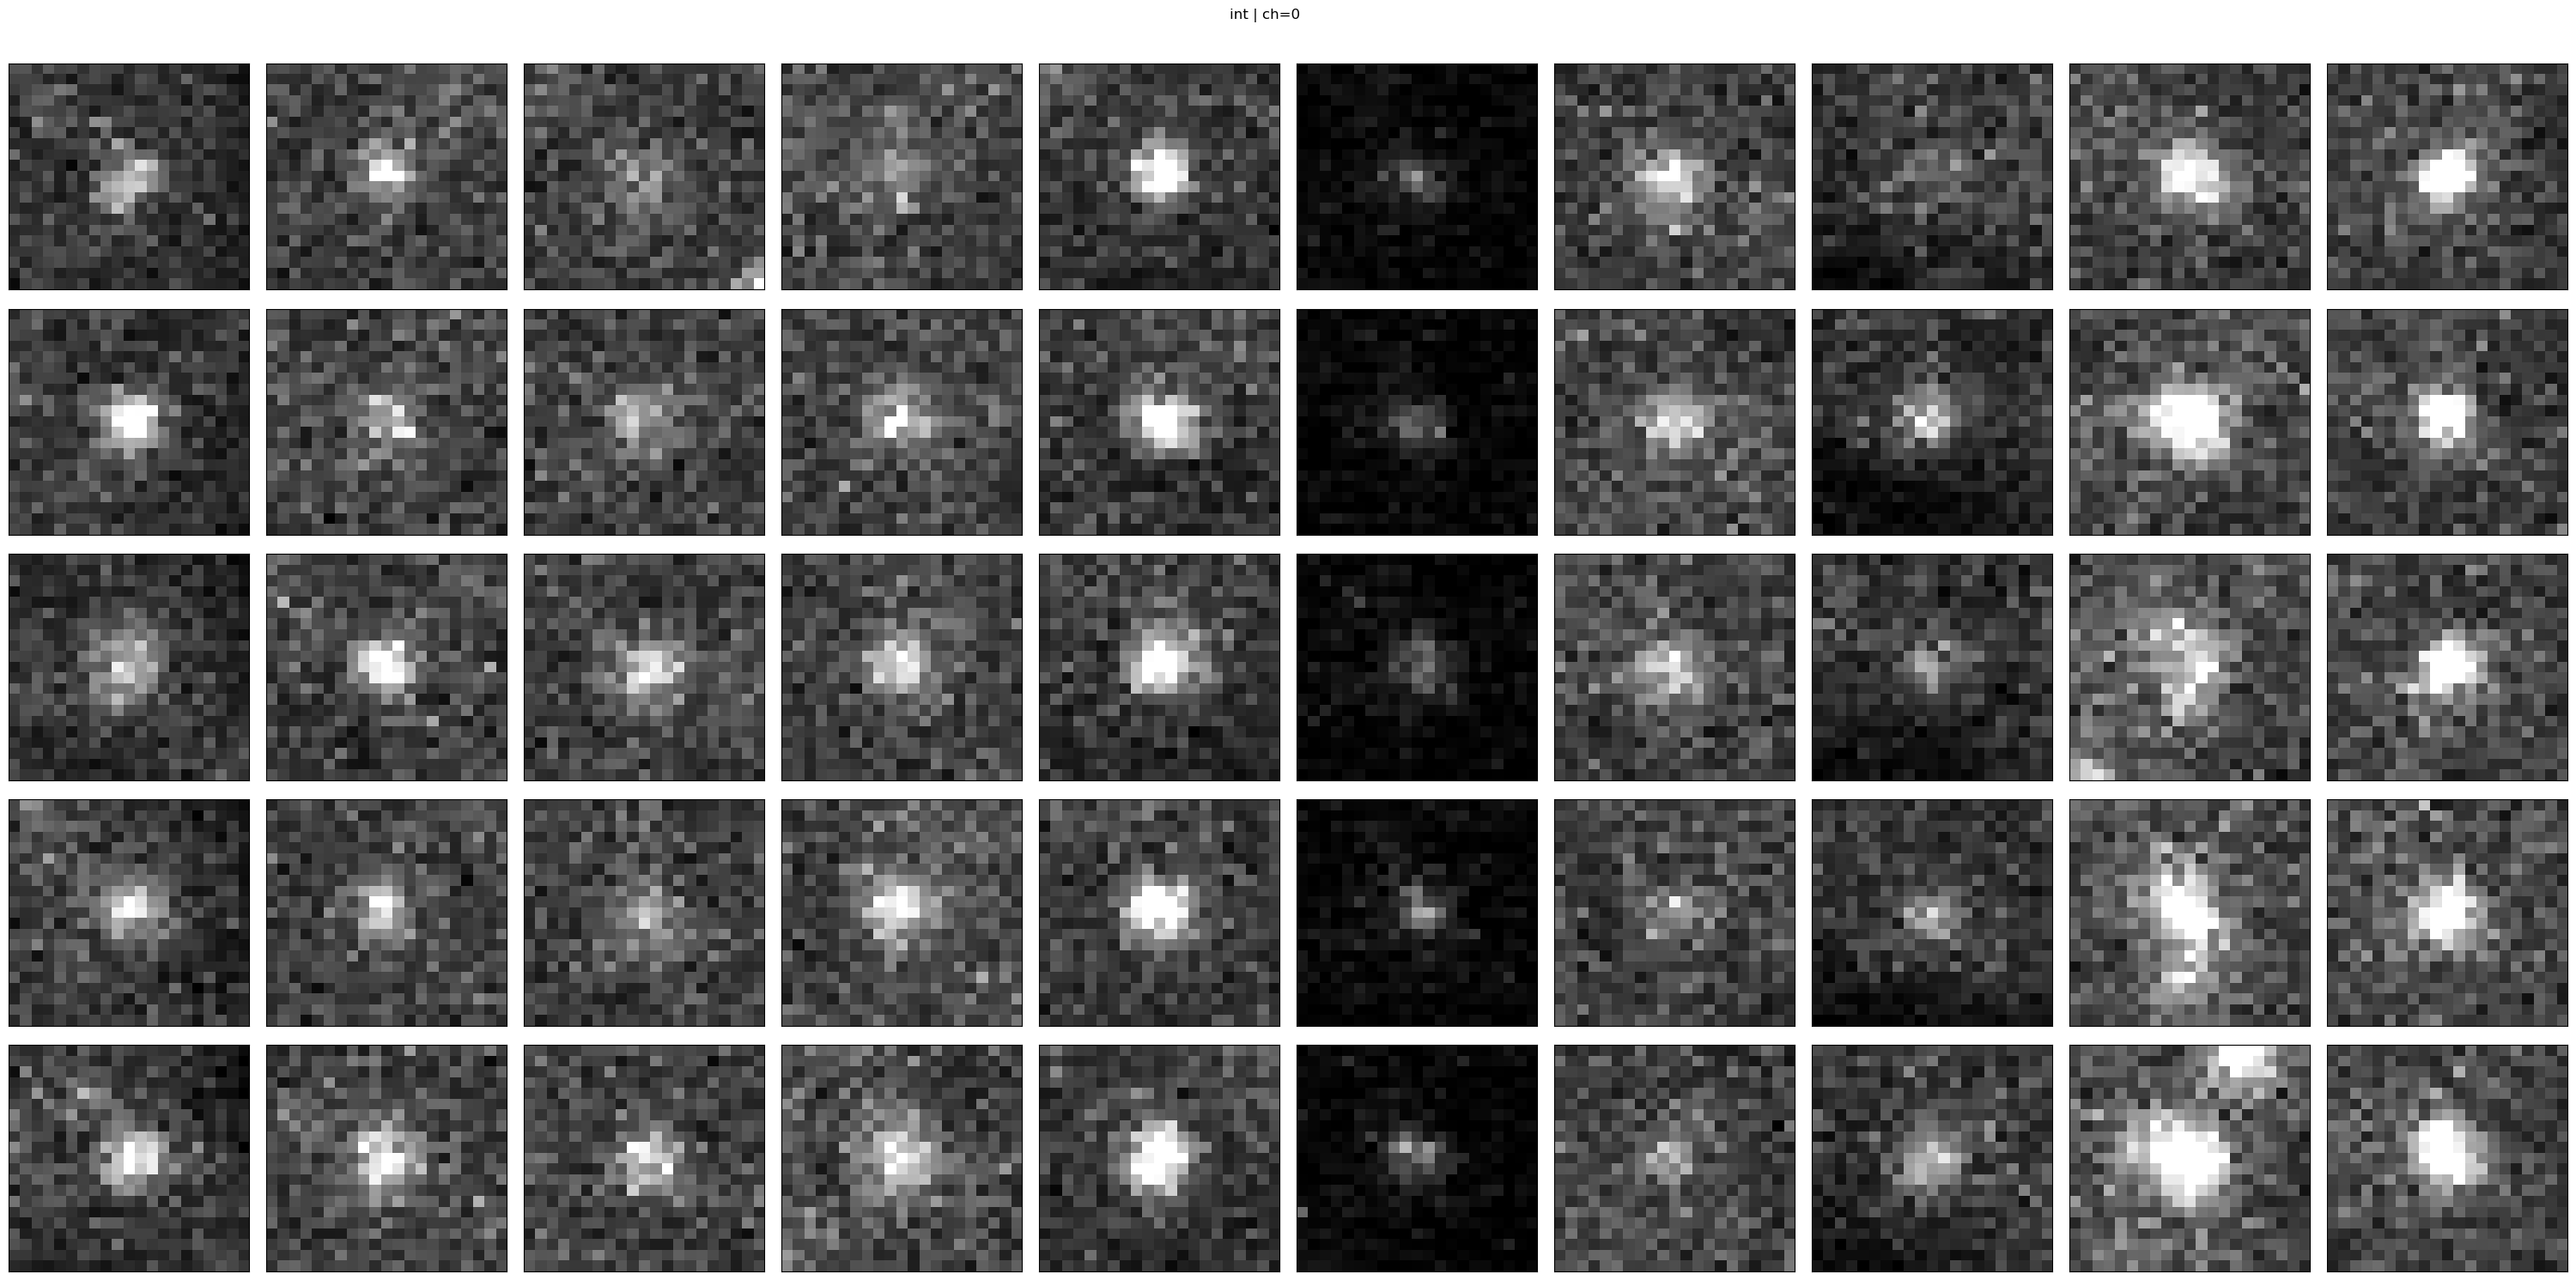

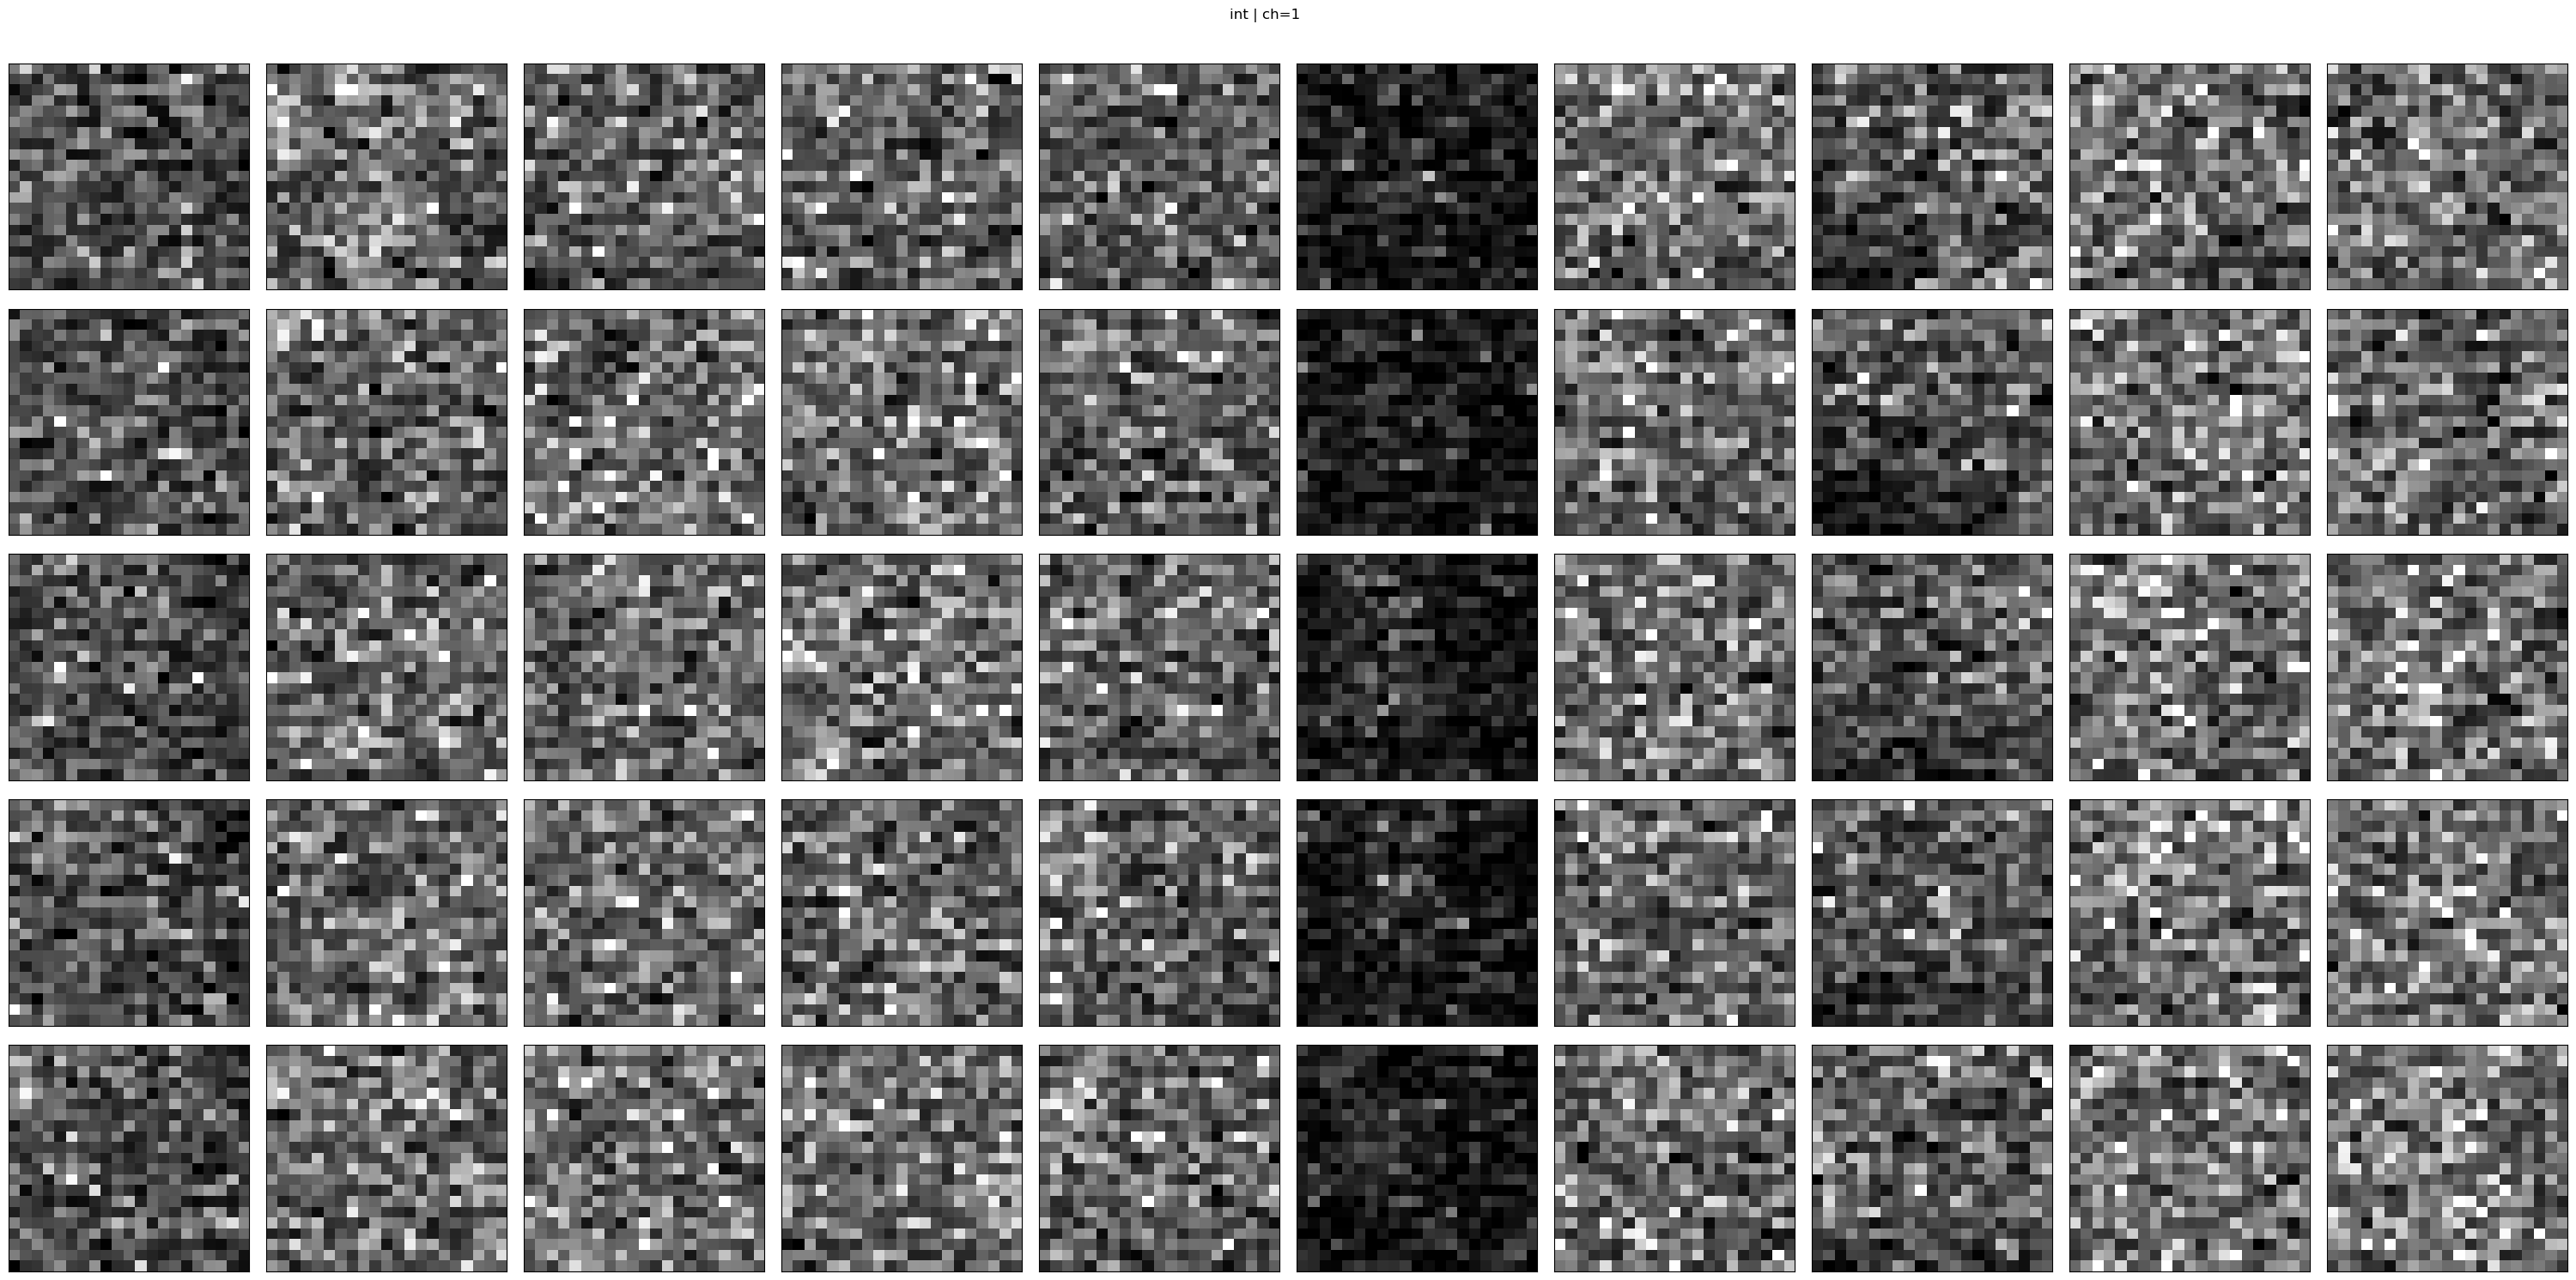

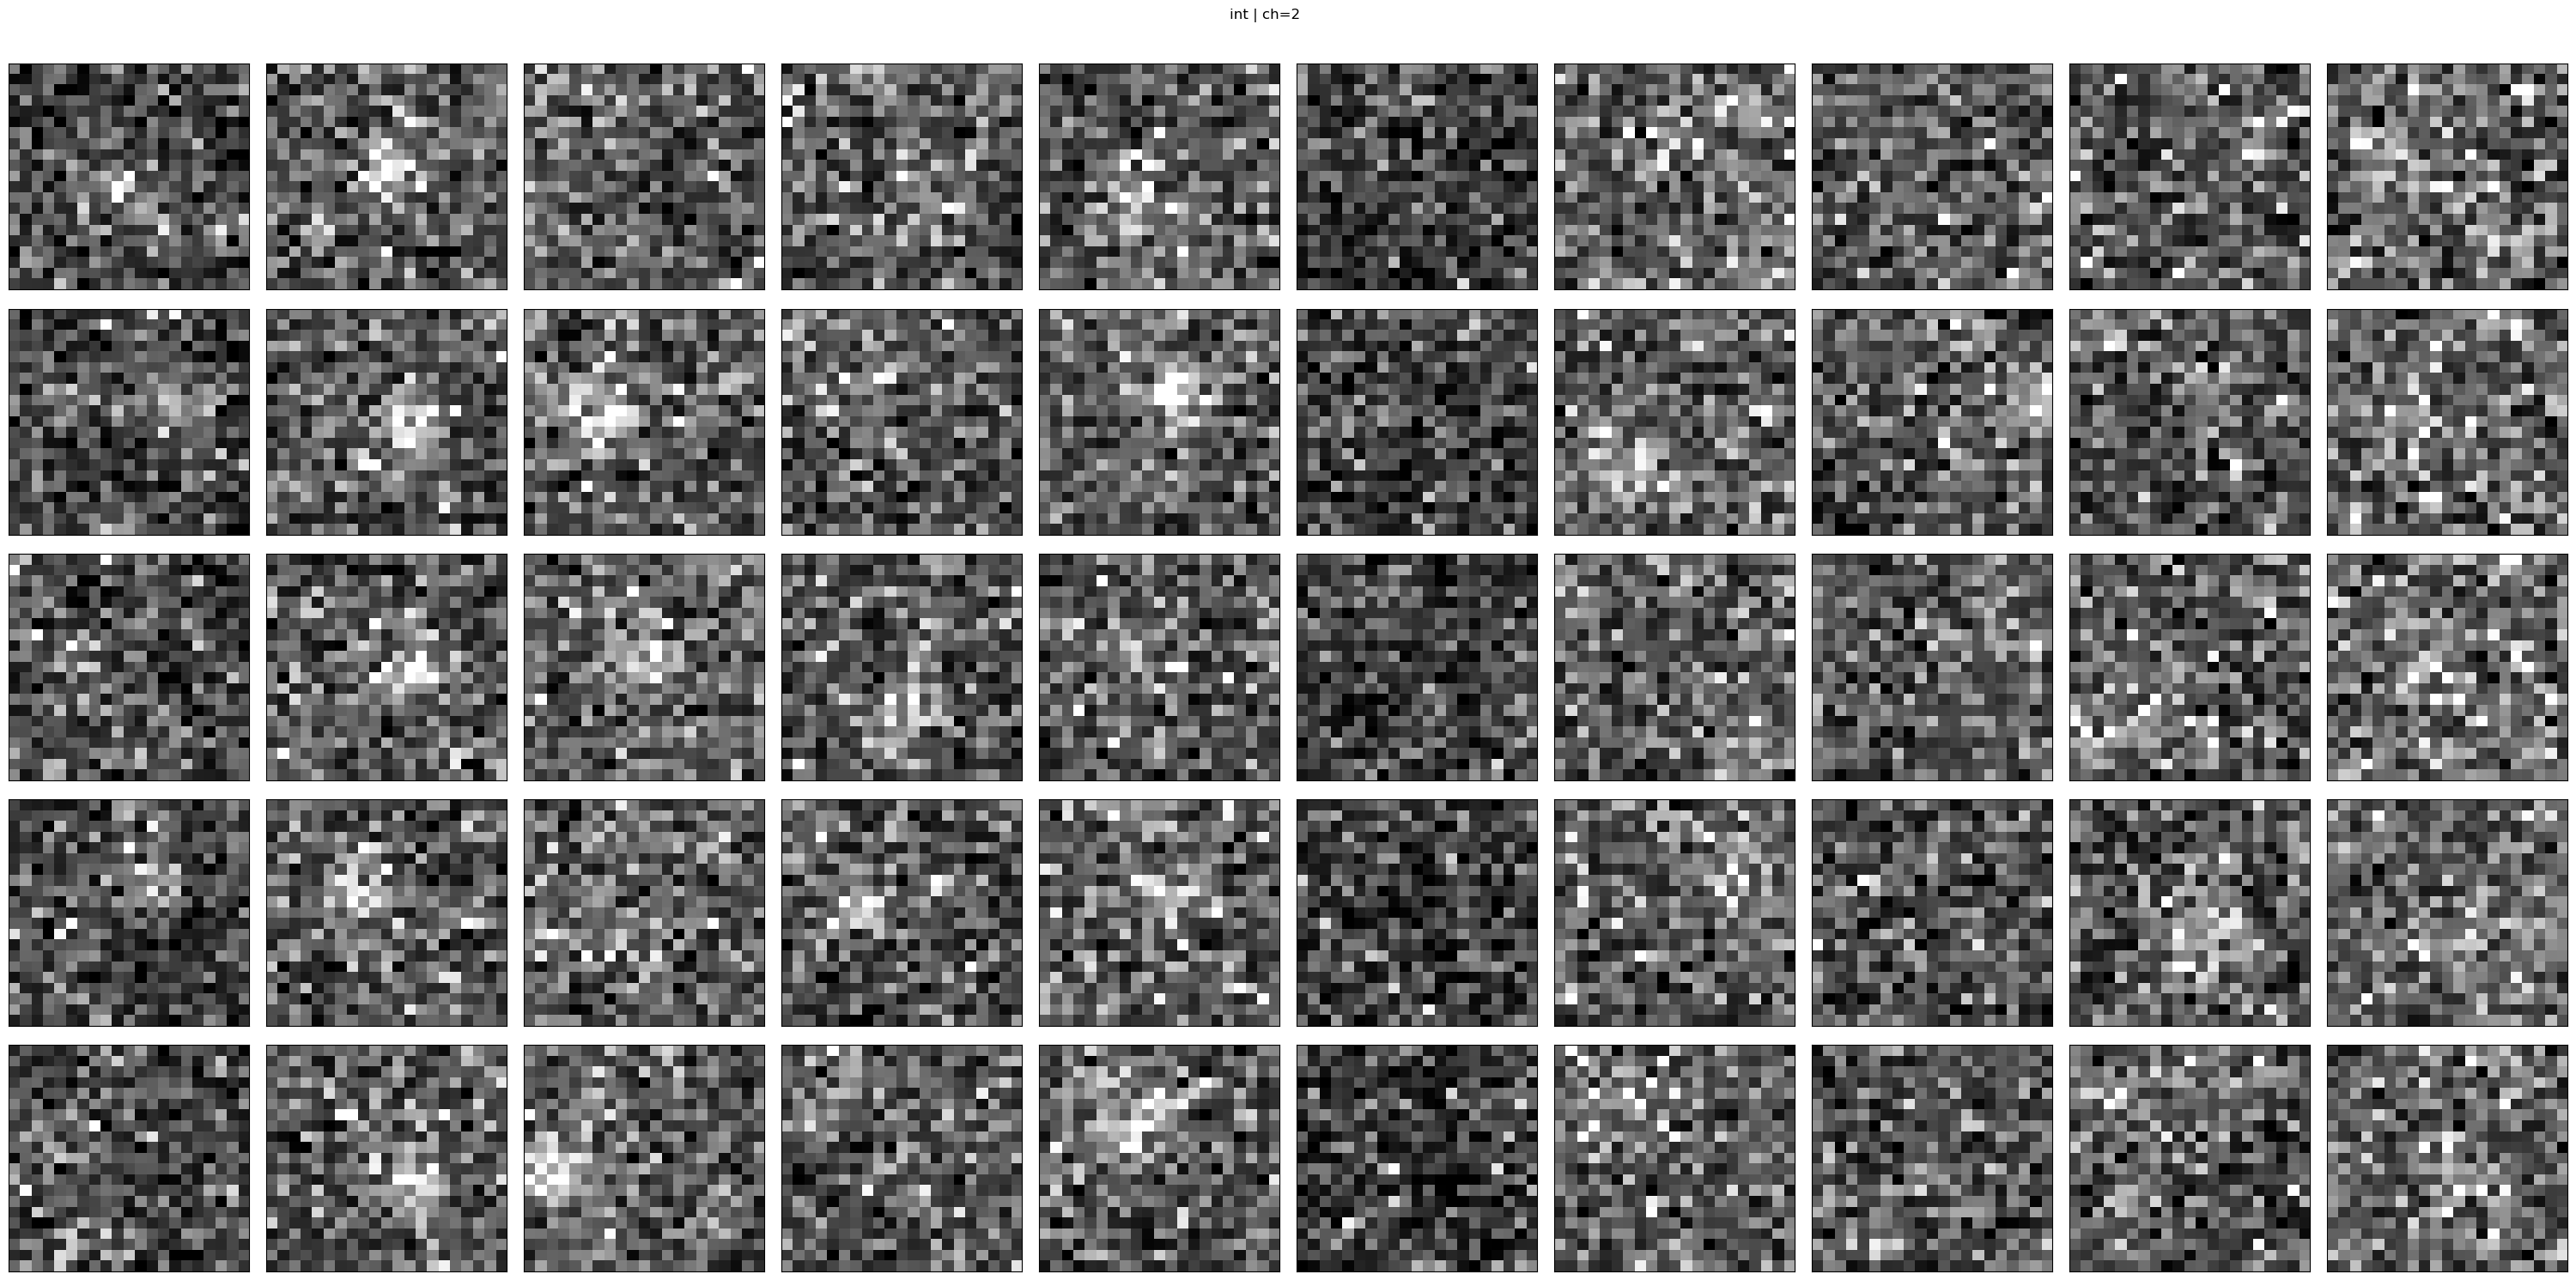

In [18]:
my_ca.isel(fov=0,z=0).plot.plot_croparray_crops(n=(0,10,1), layer='int',t=(0,5,1), col='n');

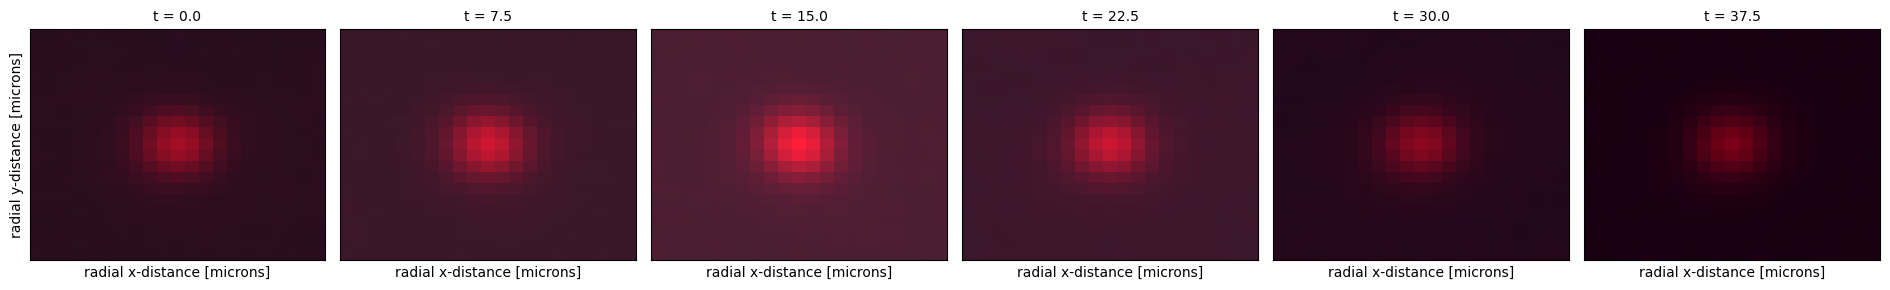

In [19]:
my_ca['int'].isel(fov=0,z=0).mean(dim=['n']).rolling(t=5, center=True, min_periods=1).mean().isel(t=slice(None, None, 5)).plot.imshow(col="t", cmap='gray',robust=True, vmin=0,vmax=10000,xticks=[],yticks=[],)